### Data setup

The dataset is not included in this repository. Place the required project data in the local `data/` directory before running the notebook. Environment-specific Colab/Drive/Practicum paths were replaced with relative paths for portability.


## Этап 0. Подготовка окружения



In [ ]:
# импортируем библиотеки, которые пригодятся для проекта
import math
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from collections import Counter
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import GPT2LMHeadModel, GPT2TokenizerFast


# фиксируем случайность
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


# выбираем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Устройство: cuda
GPU: Tesla T4


In [ ]:
# основные гиперпараметры проекта
SEED = 42
SEQ_LEN = 32
STRIDE = 8
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
LEARNING_RATE = 0.001
N_EPOCHS = 8
MIN_FREQ = 2
MAX_VOCAB_SIZE = 20000
CLIP_VALUE = 1.0
EARLY_STOPPING_PATIENCE = 3

## Этап 1. Загрузка и подготовка данных

Использую стандартные части `train`, `validation` и `test` датасета WikiText-2. Сначала посмотрю на примеры и исследуем длины непустых строк.

In [ ]:
# загружаем датасет WikiText-2
dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

print(dataset)

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [ ]:
def clean_string(text):
    # приводим текст к нижнему регистру
    text = text.lower()
    # оставляем латинские буквы, цифры и пробелы
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    # удаляем повторяющиеся пробелы и пробелы по краям
    text = re.sub(r"\s+", " ", text).strip()
    return text
def prepare_texts(raw_texts):
    cleaned_texts = [clean_string(text) for text in raw_texts]

    # удаляем пустые строки
    cleaned_texts = [text for text in cleaned_texts if text]

    return cleaned_texts


train_texts = prepare_texts(dataset["train"]["text"])
val_texts = prepare_texts(dataset["validation"]["text"])
test_texts = prepare_texts(dataset["test"]["text"])

print("Количество строк в train:", len(train_texts))
print("Количество строк в validation:", len(val_texts))
print("Количество строк в test:", len(test_texts))

Количество строк в train: 23764
Количество строк в validation: 2461
Количество строк в test: 2891


In [ ]:
for number, text in enumerate(train_texts[:5], start=1):
    print(f"Пример {number}: {text[:300]}\n")

Пример 1: valkyria chronicles iii

Пример 2: senj no valkyria 3 unrecorded chronicles japanese 3 lit valkyria of the battlefield 3 commonly referred to as valkyria chronicles iii outside japan is a tactical role playing video game developed by sega and media vision for the playstation portable released in january 2011 in japan it is the third 

Пример 3: the game began development in 2010 carrying over a large portion of the work done on valkyria chronicles ii while it retained the standard features of the series it also underwent multiple adjustments such as making the game more forgiving for series newcomers character designer raita honjou and com

Пример 4: it met with positive sales in japan and was praised by both japanese and western critics after release it received downloadable content along with an expanded edition in november of that year it was also adapted into manga and an original video animation series due to low sales of valkyria chronicle

Пример 5: gameplay



In [ ]:
# считаем длины строк в словах
train_lengths = [len(text.split()) for text in train_texts]
val_lengths = [len(text.split()) for text in val_texts]
test_lengths = [len(text.split()) for text in test_texts]


length_statistics = pd.DataFrame({
    "Выборка": ["train", "validation", "test"],
    "Количество строк": [len(train_texts), len(val_texts), len(test_texts)],
    "Средняя длина": [
        np.mean(train_lengths),
        np.mean(val_lengths),
        np.mean(test_lengths)
    ],
    "Медианная длина": [
        np.median(train_lengths),
        np.median(val_lengths),
        np.median(test_lengths)
    ],
    "95-й перцентиль": [
        np.percentile(train_lengths, 95),
        np.percentile(val_lengths, 95),
        np.percentile(test_lengths, 95)
    ]
})

display(length_statistics.round(2))

,Выборка,Количество строк,Средняя длина,Медианная длина,95-й перцентиль
0,train,23764,73.80,65.0,206.0
1,validation,2461,74.67,65.0,203.0
2,test,2891,71.50,59.0,204.5


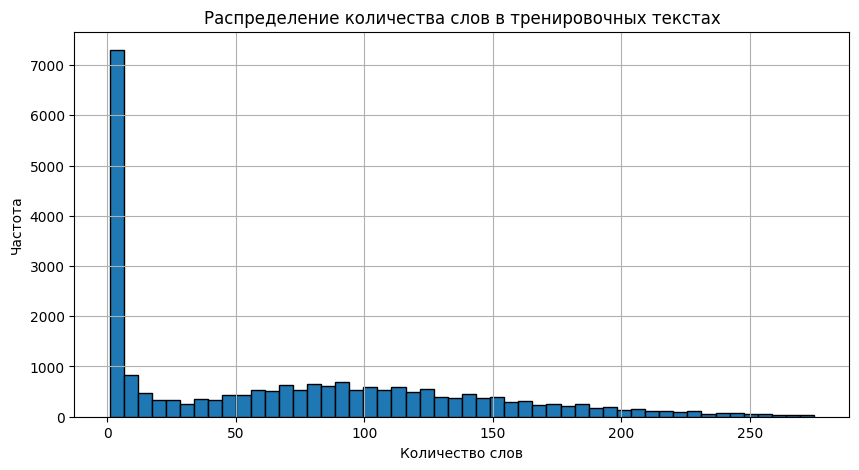

In [ ]:
# строим распределение длин тренировочных текстов
plot_limit = int(np.percentile(train_lengths, 99))

plt.figure(figsize=(10, 5))
plt.hist(
    [length for length in train_lengths if length <= plot_limit],
    bins=50,
    edgecolor="black"
)
plt.title("Распределение количества слов в тренировочных текстах")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

### Вывод по исследованию данных

После очистки в train осталось 23 764 непустые строки, в validation — 2 461, в test — 2 891. Средняя длина во всех трёх выборках близка и составляет примерно 72–75 слов, поэтому распределения выглядят согласованно.

На гистограмме видно много коротких строк и длинный правый хвост. Для обучения я выбрала последовательности длины 32: такого контекста достаточно для этого эксперимента, а вычислительные затраты остаются умеренными. Словарь дальше строится только по train, чтобы не использовать информацию из validation и test.

In [ ]:
# считаем частоты слов только на тренировочной выборке
word_counter = Counter()

for text in train_texts:
    word_counter.update(text.split())


# специальные токены
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"


# оставляем частотные слова и ограничиваем размер словаря
frequent_words = [
    word
    for word, count in word_counter.most_common()
    if count >= MIN_FREQ
]

frequent_words = frequent_words[:MAX_VOCAB_SIZE - 2]


# строим отображения слово -> индекс и индекс -> слово
idx_to_word = [PAD_TOKEN, UNK_TOKEN] + frequent_words
word_to_idx = {
    word: idx
    for idx, word in enumerate(idx_to_word)
}

PAD_IDX = word_to_idx[PAD_TOKEN]
UNK_IDX = word_to_idx[UNK_TOKEN]
vocab_size = len(idx_to_word)

print("Размер словаря:", vocab_size)
print("Пять самых частых слов:", word_counter.most_common(5))

Размер словаря: 20000
Пять самых частых слов: [('the', 130771), ('of', 57032), ('and', 50738), ('in', 45026), ('to', 39524)]


In [ ]:
# оценим покрытие словаря и долю неизвестных слов
def calculate_oov_rate(texts):
    words = [word for text in texts for word in text.split()]
    unknown_count = sum(word not in word_to_idx for word in words)

    return unknown_count / len(words)


vocabulary_statistics = pd.DataFrame({
    "Выборка": ["train", "validation", "test"],
    "Количество слов": [
        sum(len(text.split()) for text in train_texts),
        sum(len(text.split()) for text in val_texts),
        sum(len(text.split()) for text in test_texts)
    ],
    "Доля <unk>": [
        calculate_oov_rate(train_texts),
        calculate_oov_rate(val_texts),
        calculate_oov_rate(test_texts)
    ]
})

display(vocabulary_statistics.style.format({"Доля <unk>": "{:.2%}"}))

,Выборка,Количество слов,Доля
0,train,1753826,4.46%
1,validation,183770,6.94%
2,test,206718,8.04%


### Вывод по словарю

Словарь ограничен 20 000 токенами и построен только по train. Редкие и незнакомые слова заменяются на `<unk>`. Доля таких слов составила 4.46% на train, 6.94% на validation и 8.04% на test. На новых данных она ожидаемо выше, но словарь всё ещё покрывает большую часть текста.

Ограничение словаря уменьшает размер выходного слоя и ускоряет обучение. Обратная сторона решения — `<unk>` иногда появляется среди вариантов продолжения, что нужно учитывать при разборе предсказаний.

In [ ]:
# функция пословной токенизации
def encode_text(text):
    return [
        word_to_idx.get(word, UNK_IDX)
        for word in text.split()
    ]

class LanguageModelDataset(Dataset):
    def __init__(self, texts, seq_len=32, stride=8):
        self.samples = []

        for text in texts:
            token_ids = encode_text(text)

            # нужен ещё один токен для сдвинутого таргета
            if len(token_ids) < seq_len + 1:
                continue
            for start in range(0, len(token_ids) - seq_len, stride):
                sequence = token_ids[start:start + seq_len + 1]

                if len(sequence) < seq_len + 1:
                    continue

                # вход и таргет сдвинуты на один токен
                x = sequence[:-1]
                y = sequence[1:]

                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]

        return (
            torch.tensor(x, dtype=torch.long),
            torch.tensor(y, dtype=torch.long)
        )

In [ ]:
train_dataset = LanguageModelDataset(
    train_texts,
    seq_len=SEQ_LEN,
    stride=STRIDE
)

val_dataset = LanguageModelDataset(
    val_texts,
    seq_len=SEQ_LEN,
    stride=STRIDE
)

test_dataset = LanguageModelDataset(
    test_texts,
    seq_len=SEQ_LEN,
    stride=STRIDE
)


# создаём даталоадеры
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Train batches:", len(train_loader))

Train samples: 161762
Validation samples: 16861
Test samples: 18930
Train batches: 2528


In [ ]:
# проверяем сдвиг входа и таргета
x_example, y_example = train_dataset[0]

print("X:", [idx_to_word[idx] for idx in x_example[:10].tolist()])
print("Y:", [idx_to_word[idx] for idx in y_example[:10].tolist()])
print("Размер X:", x_example.shape)
print("Размер Y:", y_example.shape)

X: ['senj', 'no', 'valkyria', '3', '<unk>', 'chronicles', 'japanese', '3', 'lit', 'valkyria']
Y: ['no', 'valkyria', '3', '<unk>', 'chronicles', 'japanese', '3', 'lit', 'valkyria', 'of']
Размер X: torch.Size([32])
Размер Y: torch.Size([32])


### Вывод по подготовке последовательностей

Каждый объект датасета содержит вход и таргет длины 32. Таргет сдвинут на один токен: например, после `senj` модель должна предсказать `no`, после `no` — `valkyria` и так далее. Значит, на каждой позиции решается задача классификации следующего слова.

Шаг `stride=8` создаёт пересекающиеся контексты. В результате получилось 161 762 обучающих, 16 861 валидационный и 18 930 тестовых примеров. Для всех трёх частей созданы отдельные `Dataset` и `DataLoader`.

## Этап 2. Реализация и обучение LSTM

Модель состоит из:

- `Embedding`, который преобразует индексы слов в векторы;
- двухслойного рекуррентного блока;
- `Dropout` для регуляризации;
- линейного слоя, который выдаёт скоры всех слов словаря.

Один класс поддерживает LSTM и GRU, чтобы эксперимент проводился при одинаковых остальных условиях.

In [ ]:
class RecurrentLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=2,
        rnn_type="LSTM",
        pad_idx=0,
        dropout=0.2
    ):
        super().__init__()

        self.rnn_type = rnn_type

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
            )
        elif rnn_type == "GRU":
            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout
            )
        else:
            raise ValueError('rnn_type должен быть "LSTM" или "GRU"')

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        rnn_output, _ = self.rnn(embedded)
        rnn_output = self.dropout(rnn_output)
        logits = self.fc(rnn_output)

        return logits


def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    start_time = time.time()

    for x_batch, y_batch in tqdm(loader, desc="Обучение", leave=False):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            y_batch.reshape(-1)
        )

        loss.backward()

        # ограничиваю норму градиентов
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=CLIP_VALUE
        )

        optimizer.step()

        total_loss += loss.item()

    epoch_time = time.time() - start_time
    average_loss = total_loss / len(loader)

    return average_loss, epoch_time


def evaluate_recurrent_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                y_batch.reshape(-1)
            )

            total_loss += loss.item()

    average_loss = total_loss / len(loader)
    perplexity = math.exp(average_loss)

    return average_loss, perplexity

In [ ]:
# общая функция обучения модели
def train_model(model, train_loader, val_loader, n_epochs=3):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_perplexity": [],
        "epoch_time": []
    }

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        train_loss, epoch_time = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_perplexity = evaluate_recurrent_model(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_perplexity"].append(val_perplexity)
        history["epoch_time"].append(epoch_time)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch + 1}/{n_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Perplexity: {val_perplexity:.2f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
            f"Time: {epoch_time:.1f} sec"
        )

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping: качество на validation перестало улучшаться")
            break

    model.load_state_dict(best_state)

    return history

In [ ]:
# создаю и обучаю LSTM
lstm_model = RecurrentLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    rnn_type="LSTM",
    pad_idx=PAD_IDX
).to(device)

print("Количество параметров LSTM:", count_parameters(lstm_model))

lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    n_epochs=N_EPOCHS
)

Количество параметров LSTM: 8621600


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 1/8 | Train Loss: 6.7144 | Val Loss: 6.1139 | Val Perplexity: 452.09 | LR: 0.001000 | Time: 80.2 sec


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 2/8 | Train Loss: 6.0174 | Val Loss: 5.8336 | Val Perplexity: 341.59 | LR: 0.001000 | Time: 83.3 sec


...

Epoch 6/8 | Train Loss: 5.0472 | Val Loss: 5.6618 | Val Perplexity: 287.66 | LR: 0.001000 | Time: 85.6 sec


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 7/8 | Train Loss: 4.9302 | Val Loss: 5.6841 | Val Perplexity: 294.15 | LR: 0.000500 | Time: 85.7 sec


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 8/8 | Train Loss: 4.8088 | Val Loss: 5.6973 | Val Perplexity: 298.05 | LR: 0.000500 | Time: 85.7 sec
Early stopping: качество на validation перестало улучшаться


### Вывод по обучению LSTM

Validation perplexity LSTM снизилась с 452.09 до 284.33 и достигла минимума на 5-й эпохе. После этого train loss продолжил снижаться, а validation loss начал расти. Значит, модель стала лучше запоминать train, но перестала улучшаться на новых данных. Веса 5-й эпохи сохранены как лучшие.

### Почему обучение устроено так?

- `CrossEntropyLoss` используется, потому что на каждой позиции модель выбирает следующее слово из словаря.
- `AdamW` обновляет веса и добавляет небольшую регуляризацию через `weight_decay`.
- Gradient clipping ограничивает норму градиентов и помогает избежать их взрыва.
- `ReduceLROnPlateau` уменьшает learning rate, если validation loss перестаёт улучшаться.
- Early stopping завершает обучение после трёх эпох без улучшения. После него возвращаются веса лучшей эпохи, поэтому на test оценивается лучшая версия модели, а не последняя.

## Этап 3. Эксперимент: GRU x LSTM

Обучу GRU с теми же значениями `embedding_dim`, `hidden_dim`, `num_layers`, `seq_len`, `batch_size`, `learning_rate` и количества эпох.

In [ ]:
gru_model = RecurrentLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    rnn_type="GRU",
    pad_idx=PAD_IDX
).to(device)

print("Количество параметров GRU:", count_parameters(gru_model))

gru_history = train_model(
    gru_model,
    train_loader,
    val_loader,
    n_epochs=N_EPOCHS
)

Количество параметров GRU: 8391200


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 1/8 | Train Loss: 6.7380 | Val Loss: 6.0018 | Val Perplexity: 404.15 | LR: 0.001000 | Time: 80.9 sec


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 2/8 | Train Loss: 5.7760 | Val Loss: 5.6646 | Val Perplexity: 288.47 | LR: 0.001000 | Time: 81.5 sec


...

Epoch 5/8 | Train Loss: 4.9101 | Val Loss: 5.6239 | Val Perplexity: 276.97 | LR: 0.001000 | Time: 81.7 sec


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 6/8 | Train Loss: 4.7847 | Val Loss: 5.6523 | Val Perplexity: 284.96 | LR: 0.000500 | Time: 81.9 sec


Обучение:   0%|          | 0/2528 [00:00<?, ?it/s]

Epoch 7/8 | Train Loss: 4.6237 | Val Loss: 5.6332 | Val Perplexity: 279.56 | LR: 0.000500 | Time: 81.8 sec
Early stopping: качество на validation перестало улучшаться


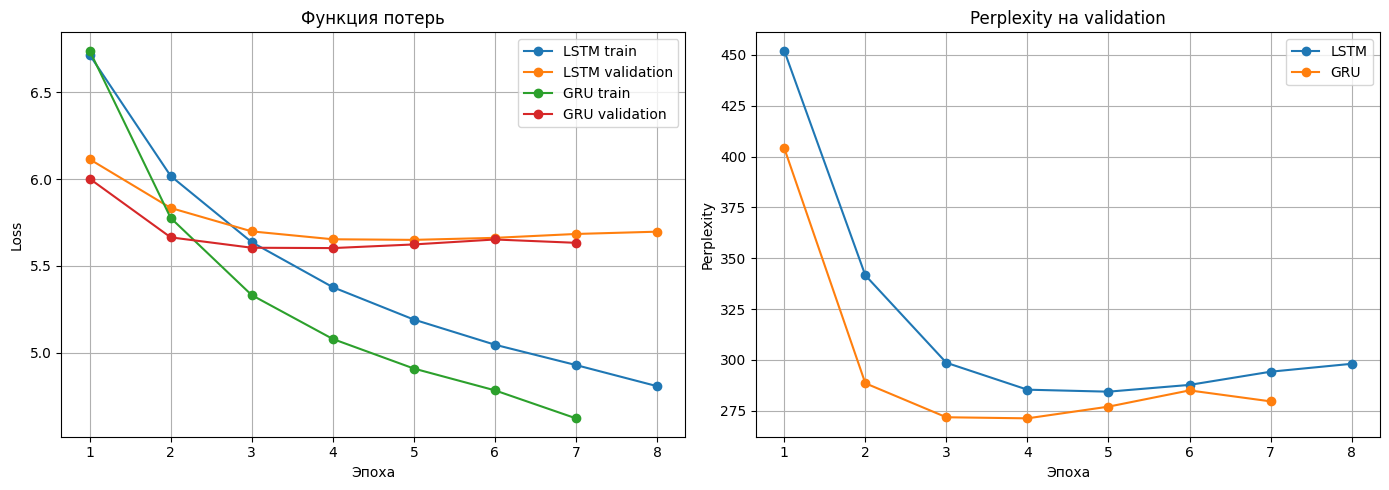

In [ ]:
lstm_epochs = range(1, len(lstm_history["train_loss"]) + 1)
gru_epochs = range(1, len(gru_history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_epochs, lstm_history["train_loss"], marker="o", label="LSTM train")
axes[0].plot(lstm_epochs, lstm_history["val_loss"], marker="o", label="LSTM validation")
axes[0].plot(gru_epochs, gru_history["train_loss"], marker="o", label="GRU train")
axes[0].plot(gru_epochs, gru_history["val_loss"], marker="o", label="GRU validation")
axes[0].set_title("Функция потерь")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(lstm_epochs, lstm_history["val_perplexity"], marker="o", label="LSTM")
axes[1].plot(gru_epochs, gru_history["val_perplexity"], marker="o", label="GRU")
axes[1].set_title("Perplexity на validation")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Perplexity")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# оцениваю лучшие версии LSTM и GRU на test
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

lstm_val_loss, lstm_val_ppl = evaluate_recurrent_model(
    lstm_model,
    val_loader,
    criterion
)

lstm_test_loss, lstm_test_ppl = evaluate_recurrent_model(
    lstm_model,
    test_loader,
    criterion
)

gru_val_loss, gru_val_ppl = evaluate_recurrent_model(
    gru_model,
    val_loader,
    criterion
)

gru_test_loss, gru_test_ppl = evaluate_recurrent_model(
    gru_model,
    test_loader,
    criterion
)

print(f"LSTM test perplexity: {lstm_test_ppl:.2f}")
print(f"GRU test perplexity: {gru_test_ppl:.2f}")

LSTM test perplexity: 263.63
GRU test perplexity: 251.84


In [ ]:
# кратко интерпретирую динамику обучения и сравниваю модели
lstm_best_epoch = int(np.argmin(lstm_history["val_loss"])) + 1
gru_best_epoch = int(np.argmin(gru_history["val_loss"])) + 1

perplexity_gain = (
    (lstm_test_ppl - gru_test_ppl) / lstm_test_ppl * 100
)

print(
    f"Лучшая эпоха LSTM: {lstm_best_epoch}; "
    f"минимальная val perplexity: {lstm_val_ppl:.2f}."
)
print(
    f"Лучшая эпоха GRU: {gru_best_epoch}; "
    f"минимальная val perplexity: {gru_val_ppl:.2f}."
)

if perplexity_gain > 0:
    print(
        f"На test GRU уменьшила perplexity относительно LSTM "
        f"на {perplexity_gain:.2f}%."
    )
else:
    print(
        f"На test LSTM уменьшила perplexity относительно GRU "
        f"на {-perplexity_gain:.2f}%."
    )

print(
    "Расхождение train и validation loss после лучшей эпохи "
    "указывает на начало переобучения; early stopping ограничивает его."
)

Лучшая эпоха LSTM: 5; минимальная val perplexity: 284.33.
Лучшая эпоха GRU: 4; минимальная val perplexity: 271.21.
На test GRU уменьшила perplexity относительно LSTM на 4.47%.
Расхождение train и validation loss после лучшей эпохи указывает на начало переобучения; early stopping ограничивает его.


### Вывод по эксперименту GRU vs LSTM

GRU достигла лучшей validation perplexity 271.21 на 4-й эпохе, а LSTM — 284.33 на 5-й. На test результат GRU также лучше: 251.84 против 263.63. Улучшение составляет около 4.47%.

Сравнение честное, потому что модели обучались на одинаковых данных и с одинаковыми `embedding_dim`, `hidden_dim`, `num_layers`, `seq_len`, `batch_size` и learning rate. GRU имеет меньше параметров и быстрее проходит эпоху, поэтому по результатам эксперимента выглядит предпочтительнее.

## Этап 4. Оценка предобученного трансформера `distilgpt2`

Теперь отдельно оценю предобученную `distilgpt2`.
Perplexity `distilgpt2` нельзя напрямую сравнивать с perplexity LSTM и GRU: рекуррентные модели работают со словами из нашего словаря, а трансформер — с BPE-токенами. Результат `distilgpt2` нужен как отдельный ориентир качества предобученной модели.

In [ ]:
# загружаем токенизатор и модель distilgpt2
gpt_tokenizer = GPT2TokenizerFast.from_pretrained("distilgpt2")
gpt_model = GPT2LMHeadModel.from_pretrained("distilgpt2").to(device)
gpt_model.eval()

gpt_parameter_count = count_parameters(gpt_model)

print("Количество параметров distilgpt2:", gpt_parameter_count)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Количество параметров distilgpt2: 81912576


In [ ]:
# функция подсчёта perplexity для distilgpt2
def evaluate_gpt2_perplexity(model, tokenizer, texts, stride=512):
    full_text = "\n\n".join(texts)

    encodings = tokenizer(
        full_text,
        return_tensors="pt",
        add_special_tokens=False,
        verbose=False
    )

    input_ids = encodings["input_ids"]
    max_length = model.config.n_positions
    sequence_length = input_ids.size(1)

    # заранее сохраняем только те позиции,
    # которые действительно потребуются для оценки
    starts = []

    for start in range(0, sequence_length, stride):
        starts.append(start)

        if start + max_length >= sequence_length:
            break

    total_negative_log_likelihood = 0.0
    total_tokens = 0
    previous_end = 0

    model.eval()

    with torch.no_grad():
        for start in tqdm(starts, desc="Оценка distilgpt2"):
            end = min(start + max_length, sequence_length)
            target_length = end - previous_end

            block = input_ids[:, start:end].to(device)
            labels = block.clone()

            # loss считаем только для новых токенов,
            # не учитывая повторно перекрывающуюся часть
            labels[:, :-target_length] = -100

            output = model(
                input_ids=block,
                labels=labels
            )

            predicted_tokens = (
                labels[:, 1:] != -100
            ).sum().item()

            total_negative_log_likelihood += (
                output.loss.item() * predicted_tokens
            )
            total_tokens += predicted_tokens
            previous_end = end

    average_loss = total_negative_log_likelihood / total_tokens
    perplexity = math.exp(average_loss)

    return average_loss, perplexity

In [ ]:
# считаю perplexity distilgpt2 на validation и test
gpt_val_loss, gpt_val_ppl = evaluate_gpt2_perplexity(
    gpt_model,
    gpt_tokenizer,
    val_texts
)

gpt_test_loss, gpt_test_ppl = evaluate_gpt2_perplexity(
    gpt_model,
    gpt_tokenizer,
    test_texts
)

print(f"distilgpt2 validation perplexity: {gpt_val_ppl:.2f}")
print(f"distilgpt2 test perplexity: {gpt_test_ppl:.2f}")

Оценка distilgpt2:   0%|          | 0/433 [00:00<?, ?it/s]

Оценка distilgpt2:   0%|          | 0/492 [00:00<?, ?it/s]

distilgpt2 validation perplexity: 75.37
distilgpt2 test perplexity: 72.95


### Вывод по `distilgpt2`

На validation модель получила perplexity 75.37, на test — 72.95. Эти значения заметно ниже результатов LSTM и GRU, но прямое численное сравнение некорректно из-за разных токенизаторов. Результат показывает преимущество предобучения на большом корпусе, а не только преимущество архитектуры трансформера.

## Этап 5. Сравнение моделей

Сначала сравним модели по числу обучаемых параметров, размеру, времени одной эпохи, скорости инференса и perplexity. Дополнительно посчитаем top-1 и top-5 accuracy рекуррентных моделей. Top-5 для автодополнения: клавиатура может показать пользователю несколько вариантов следующего слова.

Для `distilgpt2` время эпохи не указывается, потому что в проекте модель не дообучалась, а только оценивалась.

In [ ]:
# функция подсчёта top-1 и top-5 accuracy
def evaluate_topk_accuracy(model, loader):
    model.eval()

    correct_top1 = 0
    correct_top5 = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)

            logits = logits.reshape(-1, logits.size(-1))
            targets = y_batch.reshape(-1)

            top5_predictions = torch.topk(
                logits,
                k=5,
                dim=1
            ).indices

            correct_top1 += (
                top5_predictions[:, 0] == targets
            ).sum().item()

            correct_top5 += (
                top5_predictions == targets.unsqueeze(1)
            ).any(dim=1).sum().item()

            total += targets.size(0)

    return correct_top1 / total, correct_top5 / total


def model_size_mb(model):
    size_bytes = sum(
        parameter.numel() * parameter.element_size()
        for parameter in model.parameters()
    )

    return size_bytes / (1024 ** 2)


def recurrent_latency_ms(model, seq_len=32, repeats=100):
    model.eval()

    sample = torch.randint(
        low=0,
        high=vocab_size,
        size=(1, seq_len),
        device=device
    )

    # прогрев
    with torch.no_grad():
        for _ in range(10):
            model(sample)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.no_grad():
        for _ in range(repeats):
            model(sample)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    return (time.perf_counter() - start_time) * 1000 / repeats


lstm_top1, lstm_top5 = evaluate_topk_accuracy(lstm_model, test_loader)
gru_top1, gru_top5 = evaluate_topk_accuracy(gru_model, test_loader)

lstm_latency = recurrent_latency_ms(lstm_model)
gru_latency = recurrent_latency_ms(gru_model)

print(f"LSTM top-1 accuracy: {lstm_top1:.2%}")
print(f"LSTM top-5 accuracy: {lstm_top5:.2%}")
print(f"GRU top-1 accuracy: {gru_top1:.2%}")
print(f"GRU top-5 accuracy: {gru_top5:.2%}")

LSTM top-1 accuracy: 18.77%
LSTM top-5 accuracy: 36.39%
GRU top-1 accuracy: 18.72%
GRU top-5 accuracy: 36.47%


In [ ]:
results = pd.DataFrame({
    "Модель": ["LSTM", "GRU", "distilgpt2"],
    "Количество параметров": [
        count_parameters(lstm_model),
        count_parameters(gru_model),
        gpt_parameter_count
    ],
    "Размер модели, МБ": [
        model_size_mb(lstm_model),
        model_size_mb(gru_model),
        model_size_mb(gpt_model)
    ],
    "Val perplexity": [
        lstm_val_ppl,
        gru_val_ppl,
        gpt_val_ppl
    ],
    "Test perplexity": [
        lstm_test_ppl,
        gru_test_ppl,
        gpt_test_ppl
    ],
    "Среднее время эпохи, сек": [
        np.mean(lstm_history["epoch_time"]),
        np.mean(gru_history["epoch_time"]),
        np.nan
    ],
    "Инференс, мс": [
        lstm_latency,
        gru_latency,
        np.nan
    ],
    "Test top-1 accuracy": [
        lstm_top1,
        gru_top1,
        np.nan
    ],
    "Test top-5 accuracy": [
        lstm_top5,
        gru_top5,
        np.nan
    ]
})

results_display = results.copy()

for column in ["Test top-1 accuracy", "Test top-5 accuracy"]:
    results_display[column] = results_display[column].apply(
        lambda value: f"{value:.2%}" if pd.notna(value) else "—"
    )

display(results_display.round(2))

,Модель,Количество параметров,"Размер модели, МБ",Val perplexity,Test perplexity,"Среднее время эпохи, сек","Инференс, мс",Test top-1 accuracy,Test top-5 accuracy
0,LSTM,8621600,32.89,284.33,263.63,84.22,1.14,18.77%,36.39%
1,GRU,8391200,32.01,271.21,251.84,81.58,1.03,18.72%,36.47%
2,distilgpt2,81912576,312.47,75.37,72.95,NaN,NaN,—,—


In [ ]:
# функция получения пяти вариантов следующего слова
def predict_recurrent_top5(model, context):
    model.eval()

    cleaned_context = clean_string(context)
    token_ids = encode_text(cleaned_context)

    # модель может принять контекст короче 32 токенов
    token_ids = token_ids[-SEQ_LEN:]

    x = torch.tensor(
        token_ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)

    predicted_indices = torch.topk(
        logits[0, -1],
        k=5,
        dim=0
    ).indices.tolist()

    return [idx_to_word[idx] for idx in predicted_indices]


# функция получения пяти вариантов следующего токена distilgpt2
def predict_gpt2_top5(model, tokenizer, context):
    encoded = tokenizer(
        context,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**encoded).logits

    predicted_ids = torch.topk(
        logits[0, -1],
        k=5,
        dim=0
    ).indices.tolist()

    return [
        tokenizer.decode([token_id]).strip()
        for token_id in predicted_ids
    ]

In [ ]:
# сравниваю предсказания на одинаковых контекстах
contexts = [
    "the president of the",
    "he was born in",
    "the united states of",
    "this is a",
    "she looked at the",
    "at the end of the",
    "the city is located in"
]

prediction_rows = []

for context in contexts:
    prediction_rows.append({
        "Контекст": context,
        "LSTM top-5": ", ".join(predict_recurrent_top5(lstm_model, context)),
        "GRU top-5": ", ".join(predict_recurrent_top5(gru_model, context)),
        "distilgpt2 top-5": ", ".join(predict_gpt2_top5(
            gpt_model,
            gpt_tokenizer,
            context
        ))
    })

predictions = pd.DataFrame(prediction_rows)
display(predictions)

,Контекст,LSTM top-5,GRU top-5,distilgpt2 top-5
0,the president of the,"<unk>, royal, republic, united, war","<unk>, united, republic, government, parliament","United, U, US, European, world"
1,he was born in,"the, <unk>, a, his, november","the, a, <unk>, his, london","the, a, New, London, 18"
2,the united states of,"the, america, <unk>, its, a","the, america, canada, europe, independence","the, America, Europe, North, Georgia"
3,this is a,"<unk>, m, good, very, great","<unk>, major, reference, common, winged","very, great, new, good, bit"
4,she looked at the,"end, time, <unk>, same, point","end, <unk>, time, forefront, university","screen, other, girl, camera, woman"
5,at the end of the,"season, year, month, war, <unk>","year, season, war, month, second","day, year, world, century, season"
6,the city is located in,"the, a, <unk>, north, an","the, a, <unk>, galveston, an","the, a, an, central, downtown"


### Интерпретация примеров

На одних и тех же семи контекстах LSTM и GRU часто предлагают похожие частотные слова. У GRU варианты в целом выглядят немного увереннее, что согласуется с меньшей test perplexity. При этом в ответах обеих рекуррентных моделей встречается `<unk>` — это следствие ограниченного пословного словаря.

Продолжения `distilgpt2` чаще выглядят разнообразными и естественными. модель была заранее обучена на гораздо большем корпусе. Однако она почти в десять раз тяжелее рекуррентных моделей, поэтому её качество нельзя рассматривать отдельно от требований к памяти и скорости.

Для автодополнения полезнее смотреть не только на top-1, но и на top-5: интерфейс может показать пользователю несколько подходящих вариантов.

## Итоговые выводы и рекомендация

При интерпретации результатов учитываем два ограничения:

1. Perplexity рекуррентных моделей и `distilgpt2` нельзя сравнивать напрямую из-за разных токенизаторов и словарей.
2. `distilgpt2` уже была предобучена на большом корпусе, а LSTM и GRU обучались с нуля только на WikiText-2.

Следующая ячейка формирует рекомендацию для продакт-менеджера на основе фактически полученных результатов LSTM и GRU.

In [ ]:
# формирую итоговый вывод по эксперименту
lstm_params = count_parameters(lstm_model)
gru_params = count_parameters(gru_model)
lstm_time = np.mean(lstm_history["epoch_time"])
gru_time = np.mean(gru_history["epoch_time"])

print("Выводы по эксперименту:")
print(
    f"1. LSTM: test perplexity = {lstm_test_ppl:.2f}, "
    f"параметров = {lstm_params:,}, "
    f"top-5 accuracy = {lstm_top5:.2%}, "
    f"среднее время эпохи = {lstm_time:.1f} сек."
)
print(
    f"2. GRU: test perplexity = {gru_test_ppl:.2f}, "
    f"параметров = {gru_params:,}, "
    f"top-5 accuracy = {gru_top5:.2%}, "
    f"среднее время эпохи = {gru_time:.1f} сек."
)
print(
    f"3. distilgpt2: test perplexity = {gpt_test_ppl:.2f}, "
    f"параметров = {gpt_parameter_count:,}. "
    "Её perplexity приведена отдельно и напрямую с LSTM/GRU не сравнивается."
)

relative_difference = abs(gru_test_ppl - lstm_test_ppl) / min(
    gru_test_ppl,
    lstm_test_ppl
)

print("\nРекомендация:")

if gru_test_ppl <= lstm_test_ppl or relative_difference <= 0.05:
    print(
        "Для мобильного мессенджера рекомендуется GRU. "
        "Она имеет меньше параметров, а её качество сопоставимо с LSTM. "
        "Это делает GRU более подходящей при ограничениях памяти и скорости."
    )
else:
    print(
        "LSTM показала заметно меньшую perplexity, поэтому её стоит выбрать, "
        "если качество подсказок важнее размера и скорости. Если ограничения "
        "мобильного устройства строже, GRU остаётся более компактным компромиссом."
    )

print(
    "distilgpt2 можно рассматривать как более качественный, но значительно "
    "более тяжёлый вариант. Для мобильного применения ей потребуются "
    "дополнительная оптимизация, квантование или выполнение на сервере."
)

Выводы по эксперименту:
1. LSTM: test perplexity = 263.63, параметров = 8,621,600, top-5 accuracy = 36.39%, среднее время эпохи = 84.2 сек.
2. GRU: test perplexity = 251.84, параметров = 8,391,200, top-5 accuracy = 36.47%, среднее время эпохи = 81.6 сек.
3. distilgpt2: test perplexity = 72.95, параметров = 81,912,576. Её perplexity приведена отдельно и напрямую с LSTM/GRU не сравнивается.

Рекомендация:
Для мобильного мессенджера рекомендуется GRU. Она имеет меньше параметров, а её качество сопоставимо с LSTM. Это делает GRU более подходящей при ограничениях памяти и скорости.
distilgpt2 можно рассматривать как более качественный, но значительно более тяжёлый вариант. Для мобильного применения ей потребуются дополнительная оптимизация, квантование или выполнение на сервере.


## Итоговый вывод

Обе рекуррентные модели обучились нормально: validation perplexity сначала снижалась, а затем начала расти, когда train loss продолжал уменьшаться. Это говорит о начале переобучения. Лучшая точка LSTM была на 5-й эпохе, GRU — на 4-й; early stopping не дал продолжать обучение без пользы.

На тестовой выборке LSTM получила perplexity 263.63, а GRU — 251.84. Таким образом, GRU улучшила результат примерно на 4.47%. Она также оказалась немного компактнее и быстрее: 8.39 млн параметров и около 82 секунды на эпоху против 8.62 млн и 84 секунды у LSTM. Top-5 accuracy моделей почти одинаковая — около 36%.

`distilgpt2` получила test perplexity 72.95 и показала более естественные варианты продолжения, но её результат нельзя напрямую сопоставлять с LSTM и GRU из-за другой токенизации. Кроме того, модель содержит около 81.9 млн параметров и занимает примерно 312 МБ — для мобильного устройства это существенно тяжелее.

### Рекомендация продакт-менеджеру

Для первой мобильной версии я бы выбрала **GRU**. В этом эксперименте она дала лучшее качество среди рекуррентных моделей, при этом оказалась немного меньше и быстрее LSTM. Это наиболее удачный баланс между качеством подсказок и ограничениями устройства.

Если в дальнейшем главным приоритетом станет качество текста, можно рассмотреть `distilgpt2` с серверным инференсом или после дополнительной оптимизации и квантования. Для запуска непосредственно на смартфоне текущая GRU выглядит практичнее.